# Chinese Universities: Mapping the Expansion of Higher Education in China

## Introduction

This notebook documents the full data pipeline for the project **"Mapping the Expansion of Higher Education in China"**: from automatic data acquisition via two SPARQL queries, through cleaning, integration with multiple data sources, to exploratory analysis.

The project investigates four research questions:

- **RQ1 – Historical expansion**: How has the number of universities grown over time, and what historical events drove major surges?
- **RQ2 – Regional imbalance**: How unevenly are universities distributed across China's provinces — and does per-capita normalisation reshape the picture that absolute counts suggest?
- **RQ3 – Provincial founding patterns**: Which provinces developed their higher education systems early, and which are late-comers?
- **RQ4 – Geographic gravity shift**: Has the spatial center of gravity of Chinese higher education shifted over time, and if so, in which direction?

## Data Sources

Three data sources are integrated in this pipeline.

**Primary source — Wikidata (CC0 license)**  
Universities are retrieved programmatically via a SPARQL query against the public endpoint at [query.wikidata.org/sparql](https://query.wikidata.org/sparql). The query selects all entities that are instances (or subclasses) of `wd:Q3918` (*university*) located in the People's Republic of China (`wd:Q148`), and returns English + Chinese labels, inception year (`P571`), coordinates (`P625`), and administrative location (`P131`, traversed twice to reach the province level).

**Secondary source — Wikidata province population (CC0 license)**  
A second SPARQL query retrieves population figures (`P1082`) for each of China's province-level administrative units, with point-in-time qualifiers (`P585`) so the most recent census value can be selected. Coverage of all 34 units is achieved by combining China's `P150` statement with an explicit `VALUES` clause for the four direct-administered municipalities and two Special Administrative Regions. This enables per-capita normalisation in RQ2.

**Tertiary source — Chinese Geographic Macro-regions (manually compiled, CC0)**  
A classification table mapping China's 34 province-level administrative units to 7 standard geographic macro-regions (Northeast, North, East, Central, South, Southwest, Northwest), compiled from the National Bureau of Statistics of China. This enables regional grouping beyond individual provinces for RQ2 and RQ3.

**Scope note.** This project focuses on mainland China and Hong Kong. Taiwan is excluded because its higher education system follows a historical trajectory independent from the mainland after 1949; Macau is excluded because Wikidata returns no universities for it.

## Why the count differs from official statistics
The Ministry of Education of China lists 2,820 higher education institutions (2023), while our dataset contains 849 unique universities. This gap exists because: (1) Wikidata coverage skews toward well-known institutions; (2) this query targets `Q3918` (universities) only, excluding vocational colleges and junior colleges; (3) some institutions lack Wikidata entries entirely. This limitation is acknowledged in the analysis.

## Notebook Structure
- **Step 0 — Data acquisition: universities** — SPARQL query submitted to the Wikidata endpoint, results cached to `data/universities_raw.csv`
- **Step 0b — Data acquisition: province populations** — second SPARQL query, results cached to `data/province_population_raw.csv`
- **Step 1 — Data loading & profiling** — inspect raw output, missing values
- **Step 2 — Deduplication** — resolve duplicate rows caused by multiple P131 values per entity
- **Step 3 — Feature engineering** — parse coordinates, create decade column, normalize province names
- **Step 3b — Data integration: macro-regions** — merge with the macro-region classification
- **Step 3c — Data integration: populations** — keep the latest census year per province, exclude Taiwan and Macau
- **Step 4 — Exploratory Data Analysis** — missing values, founding-year distribution, absolute vs per-capita province ranking
- **Step 5 — Aggregations & export** — build `province_summary.csv` (with `univ_per_million`), `decade_province.csv`, `mean_center.csv`, `region_summary.csv`



## Step 0 – Data Acquisition via SPARQL

The cell below defines the SPARQL query used to retrieve all Chinese universities from Wikidata, then executes it against the public endpoint and stores the raw output to `data/universities_raw.csv`.

**Query logic:**
- `?univ wdt:P31/wdt:P279* wd:Q3918` — the entity is (a subclass of) *university*
- `?univ wdt:P17 wd:Q148` — located in the country China
- Seven `OPTIONAL` blocks retrieve English/Chinese labels, inception year (extracted via `YEAR(?inception)`), coordinates, city, and province (via double `P131` traversal)

The `OPTIONAL` clauses mean rows are not dropped when a field is missing — this is why the raw output contains duplicates (Wikidata returns one row per combination of multiple P131 values), which we resolve in Step 2.

**Caching:** the query is only re-submitted if the raw CSV does not already exist locally. This keeps the notebook reproducible without repeatedly hitting the Wikidata endpoint.


In [1]:
# If SPARQLWrapper is not installed in your environment:  !pip install SPARQLWrapper
import os
import re
import warnings
import numpy as np
import pandas as pd
from SPARQLWrapper import SPARQLWrapper, JSON

warnings.filterwarnings("ignore")

# ── SPARQL query: Chinese universities ───────────────────────────────────
SPARQL_QUERY = """
SELECT DISTINCT ?univ ?univLabel_en ?univLabel_zh ?inceptionYear ?coord ?cityLabel ?provinceLabel
WHERE {
  ?univ wdt:P31/wdt:P279* wd:Q3918 .
  ?univ wdt:P17 wd:Q148 .

  OPTIONAL { ?univ rdfs:label ?univLabel_en . FILTER(LANG(?univLabel_en) = "en") }
  OPTIONAL { ?univ rdfs:label ?univLabel_zh . FILTER(LANG(?univLabel_zh) = "zh") }
  OPTIONAL {
    ?univ wdt:P571 ?inception .
    BIND(YEAR(?inception) AS ?inceptionYear)
  }
  OPTIONAL { ?univ wdt:P625 ?coord . }
  OPTIONAL { ?univ wdt:P131 ?city .
    ?city rdfs:label ?cityLabel . FILTER(LANG(?cityLabel) = "en") }
  OPTIONAL { ?univ wdt:P131 ?city2 .
    ?city2 wdt:P131 ?province .
    ?province rdfs:label ?provinceLabel . FILTER(LANG(?provinceLabel) = "en") }
}
ORDER BY ?univLabel_en
"""

WIKIDATA_ENDPOINT = "https://query.wikidata.org/sparql"
# Wikidata requires a descriptive User-Agent string (see their API etiquette)
USER_AGENT = "ChineseUnivVizBot/1.0 (UniBo InfoViz 2025; contact via GitHub repo)"


def fetch_from_wikidata(query: str) -> pd.DataFrame:
    """Submit a SPARQL query to Wikidata and return a flat DataFrame.

    Column names are derived from the query's SELECT variables, so the
    same function works for any query (universities, populations, etc.).
    """
    sparql = SPARQLWrapper(WIKIDATA_ENDPOINT, agent=USER_AGENT)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    results = sparql.queryAndConvert()
    columns  = results["head"]["vars"]
    bindings = results["results"]["bindings"]
    rows = [{c: b.get(c, {}).get("value", "") for c in columns} for b in bindings]
    return pd.DataFrame(rows, columns=columns)


In [2]:
os.makedirs("data", exist_ok=True)
RAW_PATH = "data/universities_raw.csv"

# Caching: only re-query Wikidata if the raw file is absent.
# Delete universities_raw.csv if you want to force a fresh fetch.
if os.path.exists(RAW_PATH):
    df_raw = pd.read_csv(RAW_PATH)
    print(f"Loaded cached SPARQL output from {RAW_PATH}")
else:
    print("Querying Wikidata... (typical runtime: 20-60 seconds)")
    df_raw = fetch_from_wikidata(SPARQL_QUERY)
    df_raw.to_csv(RAW_PATH, index=False)
    print(f"Saved raw SPARQL output to {RAW_PATH}")

print(f"Raw rows: {len(df_raw)}   |   Unique universities (URI): {df_raw['univ'].nunique()}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head()


Loaded cached SPARQL output from data/universities_raw.csv
Raw rows: 954   |   Unique universities (URI): 849
Columns: ['univ', 'univLabel_en', 'univLabel_zh', 'inceptionYear', 'coord', 'cityLabel', 'provinceLabel']


,univ,univLabel_en,univLabel_zh,inceptionYear,coord,cityLabel,provinceLabel
0,http://www.wikidata.org/entity/Q4495765,NaN,哈尔滨法学院,1920.0,Point(126.6294111 45.74843611),Harbin,Heilongjiang
1,http://www.wikidata.org/entity/Q65583468,NaN,陕西老年大学,NaN,Point(108.936910819 34.260281353),Beilin District,Xi'an
2,http://www.wikidata.org/entity/Q115203157,NaN,中国人民解放军陆军边海防学院昆明校区,NaN,Point(102.789698 24.997333),Kunming,Yunnan
3,http://www.wikidata.org/entity/Q130640081,NaN,NaN,NaN,Point(118.601084 35.738653),Yishui County,Linyi
4,http://www.wikidata.org/entity/Q130640114,NaN,NaN,NaN,Point(117.965191 35.276633),Fei County,Linyi


## Step 0b – Second SPARQL Query: Province Population

To enable per-capita normalisation in RQ2, we retrieve the population of
each Chinese province-level administrative unit from Wikidata.

**Query logic.** China (`wd:Q148`) links to its province-level subdivisions
via `P150` (*contains administrative territorial entity*), but on `Q148`
this property only covers ordinary provinces and autonomous regions. The
four direct-administered municipalities (Beijing, Shanghai, Tianjin,
Chongqing) and the two Special Administrative Regions (Hong Kong, Macau)
are modelled elsewhere in the ontology, so we add them explicitly via a
`VALUES` clause to guarantee full coverage of all province-level units.

For each unit, `P1082` (*population*) is retrieved together with its
`P585` (*point in time*) qualifier — each province has many historical
population figures, and the qualifier is essential for later selecting
the most recent one.

Like Step 0, the raw output is cached to `data/province_population_raw.csv`
for reproducibility.


In [3]:
# ── SPARQL query: population of Chinese province-level units ────────────
POPULATION_QUERY = """
SELECT ?province ?provinceLabel ?population ?pointInTime
WHERE {
  {
    wd:Q148 wdt:P150 ?province .
  }
  UNION
  {
    # Direct-administered municipalities and Special Administrative Regions
    # that are not reached via Q148's P150 statement.
    VALUES ?province {
      wd:Q956    # Beijing
      wd:Q8686   # Shanghai
      wd:Q11736  # Tianjin
      wd:Q11725  # Chongqing
      wd:Q8646   # Hong Kong
      wd:Q14773  # Macau
    }
  }
  ?province p:P1082 ?popStatement .
  ?popStatement ps:P1082 ?population .
  OPTIONAL { ?popStatement pq:P585 ?pointInTime . }
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en" . }
}
ORDER BY ?province DESC(?pointInTime)
"""

POP_RAW_PATH = "data/province_population_raw.csv"

# Caching: only re-query Wikidata if the raw file is absent.
# Delete province_population_raw.csv if you want to force a fresh fetch.
if os.path.exists(POP_RAW_PATH):
    df_pop_raw = pd.read_csv(POP_RAW_PATH)
    print(f"Loaded cached SPARQL output from {POP_RAW_PATH}")
else:
    print("Querying Wikidata for province populations... (typical runtime: 5-15 seconds)")
    df_pop_raw = fetch_from_wikidata(POPULATION_QUERY)
    df_pop_raw.to_csv(POP_RAW_PATH, index=False)
    print(f"Saved raw SPARQL output to {POP_RAW_PATH}")

print(f"Raw rows: {len(df_pop_raw)}   |   Unique provinces: {df_pop_raw['provinceLabel'].nunique()}")
df_pop_raw.head()


Loaded cached SPARQL output from data/province_population_raw.csv
Raw rows: 246   |   Unique provinces: 33


,province,provinceLabel,population,pointInTime
0,http://www.wikidata.org/entity/Q11725,Chongqing,32054159,2020-01-01T00:00:00Z
1,http://www.wikidata.org/entity/Q11725,Chongqing,32054159,2020-01-01T00:00:00Z
2,http://www.wikidata.org/entity/Q11725,Chongqing,30170000,2015-01-01T00:00:00Z
3,http://www.wikidata.org/entity/Q11725,Chongqing,30170000,2015-01-01T00:00:00Z
4,http://www.wikidata.org/entity/Q11725,Chongqing,28846170,2010-01-01T00:00:00Z


## Step 1 – Understand the Raw Data

In [4]:
print('=== Missing values ===')
print(df_raw.isnull().sum())
print()
print('=== Empty strings ===')
print((df_raw == '').sum())
print()
print(f'Unique universities (by URI): {df_raw["univ"].nunique()}')

=== Missing values ===
univ               0
univLabel_en      17
univLabel_zh      28
inceptionYear    104
coord            325
cityLabel         90
provinceLabel     89
dtype: int64

=== Empty strings ===
univ             0
univLabel_en     0
univLabel_zh     0
inceptionYear    0
coord            0
cityLabel        0
provinceLabel    0
dtype: int64

Unique universities (by URI): 849


In [5]:
# Why are there duplicate rows?
# Wikidata stores multiple P131 (located in) values per entity,
# and some entities have multiple inception dates or coordinates.
# The SPARQL OPTIONAL joins multiply rows for each combination.

dup_uris = df_raw[df_raw.duplicated(subset='univ', keep=False)]
print(f'Rows involved in duplicates: {len(dup_uris)}')
print(f'Unique URIs with duplicates: {dup_uris["univ"].nunique()}')
print()
# Show one example
example = df_raw[df_raw['univLabel_en'] == 'Beijing Technology and Business University']
print('Example – Beijing Technology and Business University:')
example[['univLabel_en','inceptionYear','coord','cityLabel','provinceLabel']]

Rows involved in duplicates: 152
Unique URIs with duplicates: 47

Example – Beijing Technology and Business University:


,univLabel_en,inceptionYear,coord,cityLabel,provinceLabel
64,Beijing Technology and Business University,1950.0,Point(116.30847 39.9238),Haidian District,People's Republic of China
65,Beijing Technology and Business University,1950.0,Point(116.30847 39.9238),Fangshan District,People's Republic of China
66,Beijing Technology and Business University,1950.0,Point(116.30847 39.9238),Beijing,People's Republic of China
67,Beijing Technology and Business University,1950.0,Point(116.30847 39.9238),Haidian District,Beijing
68,Beijing Technology and Business University,1950.0,Point(116.30847 39.9238),Fangshan District,Beijing
69,Beijing Technology and Business University,1950.0,Point(116.30847 39.9238),Beijing,Beijing


## Step 2 – Deduplication Strategy

For each unique university URI, we keep:
- **inceptionYear**: take the **minimum** (earliest founding year)
- **coord**: take the **first non-empty** value
- **provinceLabel**: apply a city→province mapping, then take the most specific province-level value
- **Labels**: take first non-empty English / Chinese label

In [6]:
# Province normalization map: city/district → province
CITY_TO_PROVINCE = {
    # Beijing districts
    'Haidian District': 'Beijing', 'Chaoyang District': 'Beijing',
    'Changping District': 'Beijing', 'Daxing District': 'Beijing',
    'Dongcheng District': 'Beijing', 'Xicheng District': 'Beijing',
    'Shijingshan District': 'Beijing', 'Fengtai District': 'Beijing',
    # Cities that are themselves provinces/municipalities
    'Beijing': 'Beijing', 'Shanghai': 'Shanghai',
    'Tianjin': 'Tianjin', 'Chongqing': 'Chongqing',
    # Guangdong
    'Shenzhen': 'Guangdong', 'Guanghan': 'Sichuan',
    'Nansha District': 'Guangdong', 'Tianhe District': 'Guangdong',
    'Nanshan District': 'Guangdong', 'Dongli District': 'Tianjin',
    # Jiangsu
    'Nanjing': 'Jiangsu', 'Suzhou': 'Jiangsu',
    'Changzhou Subdistrict': 'Jiangsu',
    # Zhejiang
    'Hangzhou': 'Zhejiang',
    # Fujian
    'Xiamen': 'Fujian', 'Jianyang': 'Fujian', 'Changle District': 'Fujian',
    # Liaoning
    'Fushan District': 'Liaoning',
    # Hubei
    'Wuhan': 'Hubei', 'Hongshan District': 'Hubei',
    # Hunan
    'Changsha': 'Hunan', 'Shaoyang County': 'Hunan', 'Xupu County': 'Hunan',
    # Sichuan
    'Chengdu': 'Sichuan', 'Liangshan Yi Autonomous Prefecture': 'Sichuan',
    # Jiangxi
    'Nanchang County': 'Jiangxi', "Ji'an": 'Jiangxi', 'Fengxin County': 'Jiangxi',
    # Heilongjiang
    'Harbin': 'Heilongjiang',
    # Shaanxi
    "Xi'an": 'Shaanxi', 'Xianyang': 'Shaanxi', 'Yanta District': 'Shaanxi',
    # Shanxi
    'Taiyuan': 'Shanxi', 'Taigu District': 'Shanxi', 'Jiangzhou District': 'Shanxi',
    # Henan
    'Zhengzhou': 'Henan', 'Kaifeng': 'Henan',
    'Longzihu District': 'Henan', "Jian'an District": 'Henan',
    # Shandong
    'Qingdao': 'Shandong', 'Weifang': 'Shandong',
    'Linyi': 'Shandong', 'Jining': 'Shandong',
    # Guangxi
    'Nanning': 'Guangxi',
    # Anhui
    'Hefei': 'Anhui',
    # Hebei
    'Langfang': 'Hebei', 'Yanshan County': 'Hebei',
    # Jilin
    'Jilin City': 'Jilin', 'Changchun': 'Jilin',
    'Yanbian Korean Autonomous Prefecture': 'Jilin', 'Dongfeng District': 'Jilin',
    # Yunnan
    'Wuhua District': 'Yunnan', 'Dali Bai Autonomous Prefecture': 'Yunnan',
    # Xinjiang
    'Aksu Prefecture': 'Xinjiang', 'Kashgar Prefecture': 'Xinjiang',
    # Hong Kong
    'Southern District': 'Hong Kong', 'Gongshu District': 'Zhejiang',
    'Kowloon City District': 'Hong Kong', 'Yau Tsim Mong District': 'Hong Kong',
    # Too broad – discard
    "People's Republic of China": None,
}

def normalize_province(province_val):
    if not isinstance(province_val, str) or province_val.strip() == '':
        return np.nan
    p = province_val.strip()
    if p in CITY_TO_PROVINCE:
        return CITY_TO_PROVINCE[p]
    return p  # already a province-level name

df_raw['province_norm'] = df_raw['provinceLabel'].apply(normalize_province)
print('Province normalization preview:')
print(df_raw[['provinceLabel','province_norm']].drop_duplicates().head(15))

Province normalization preview:
                 provinceLabel province_norm
0                 Heilongjiang  Heilongjiang
1                        Xi'an       Shaanxi
2                       Yunnan        Yunnan
3                        Linyi      Shandong
5        Changzhou Subdistrict       Jiangsu
6                      Sichuan       Sichuan
7                          NaN           NaN
17                    Liaoning      Liaoning
18                     Shaanxi       Shaanxi
20                       Anhui         Anhui
34                       Henan         Henan
37  People's Republic of China          None
43                       Jilin         Jilin
46            Fengtai District       Beijing
48            Haidian District       Beijing


In [7]:
def first_nonempty(series):
    vals = series.dropna().loc[series.dropna() != '']
    return vals.iloc[0] if len(vals) > 0 else np.nan

def best_province(series):
    """Pick the most specific province-level value (non-null, not 'People's Republic of China')."""
    vals = series.dropna()
    vals = vals[vals != "People's Republic of China"]
    return vals.iloc[0] if len(vals) > 0 else np.nan

df_clean = df_raw.groupby('univ', as_index=False).agg(
    univLabel_en   = ('univLabel_en',   first_nonempty),
    univLabel_zh   = ('univLabel_zh',   first_nonempty),
    inceptionYear  = ('inceptionYear',  'min'),
    coord          = ('coord',          first_nonempty),
    province       = ('province_norm',  best_province),
)

print(f'After deduplication: {len(df_clean)} rows (expected ~849)')
df_clean.head()

After deduplication: 849 rows (expected ~849)


,univ,univLabel_en,univLabel_zh,inceptionYear,coord,province
0,http://www.wikidata.org/entity/Q100998778,Taizhou University,NaN,NaN,NaN,NaN
1,http://www.wikidata.org/entity/Q1018771,Dalian Naval Academy,中国人民解放军海军大连舰艇学院,1949.0,Point(121.66288889 38.8785),Liaoning
2,http://www.wikidata.org/entity/Q1022929,Hubei University,湖北大学,1931.0,Point(114.3175 30.5605),Hubei
3,http://www.wikidata.org/entity/Q10267326,Shandong University of Technology,山东工业大学,1949.0,NaN,NaN
4,http://www.wikidata.org/entity/Q1027478,Dalian University of Foreign Languages,大连外国语大学,1964.0,NaN,Liaoning


## Step 3 – Feature Engineering

In [8]:
# 3a. Parse coordinates → longitude, latitude
def parse_coord(c):
    if not isinstance(c, str) or c.strip() == '':
        return np.nan, np.nan
    m = re.match(r'Point\(([\d\.\-]+)\s+([\d\.\-]+)\)', c)
    if m:
        return float(m.group(1)), float(m.group(2))
    return np.nan, np.nan

df_clean[['longitude', 'latitude']] = pd.DataFrame(
    df_clean['coord'].apply(parse_coord).tolist(), index=df_clean.index
)
df_clean.drop(columns='coord', inplace=True)

# 3b. Create display name: English if available, else Chinese
df_clean['name'] = df_clean['univLabel_en'].fillna(df_clean['univLabel_zh'])

# 3c. Decade column for time-series grouping
df_clean['inceptionYear'] = pd.to_numeric(df_clean['inceptionYear'], errors='coerce')
df_clean['decade'] = (df_clean['inceptionYear'] // 10 * 10).astype('Int64')

print('Feature engineering complete.')
df_clean[['name','inceptionYear','decade','longitude','latitude','province']].head(10)

Feature engineering complete.


,name,inceptionYear,decade,longitude,latitude,province
0,Taizhou University,NaN,<NA>,NaN,NaN,NaN
1,Dalian Naval Academy,1949.0,1940,121.662889,38.87850,Liaoning
2,Hubei University,1931.0,1930,114.317500,30.56050,Hubei
3,Shandong University of Technology,1949.0,1940,NaN,NaN,NaN
4,Dalian University of Foreign Languages,1964.0,1960,NaN,NaN,Liaoning
5,College of Military Culture at the PLA Nationa...,1960.0,1960,116.325000,39.95590,NaN
6,Beijing University of Chinese Medicine,1956.0,1950,116.422130,39.96985,Beijing
7,North University of China,1941.0,1940,NaN,NaN,Shanxi
8,郑州工业大学,NaN,<NA>,NaN,NaN,NaN
9,黃埔海軍學校,1887.0,1880,NaN,NaN,Jiangsu


In [9]:
# 3d. Filter out obvious outliers in year
# Modern universities in China: realistically 1850–2025
year_check = df_clean[df_clean['inceptionYear'].notna()]
print('Year range before filter:')
print(year_check['inceptionYear'].describe())
print('\nSuspicious years (< 1850 or > 2025):')
print(df_clean[(df_clean['inceptionYear'] < 1850) | (df_clean['inceptionYear'] > 2025)]
      [['name','inceptionYear']])

Year range before filter:
count     746.000000
mean     1954.930295
std        50.125994
min       976.000000
25%      1946.000000
50%      1955.000000
75%      1979.000000
max      2025.000000
Name: inceptionYear, dtype: float64

Suspicious years (< 1850 or > 2025):
                                          name  inceptionYear
91      Sichuan University of Arts and Science         1821.0
305  Xi'an University of Finance and Economics         1579.0
377                 Qiongtai Normal University         1705.0
632                           Hunan University          976.0


In [10]:
# Keep years in valid range; set others to NaN
df_clean.loc[
    (df_clean['inceptionYear'] < 1850) | (df_clean['inceptionYear'] > 2025),
    ['inceptionYear', 'decade']
] = np.nan

print(f'Final dataset: {len(df_clean)} universities')
print(f'With inception year: {df_clean["inceptionYear"].notna().sum()}')
print(f'With coordinates:    {df_clean["longitude"].notna().sum()}')
print(f'With province:       {df_clean["province"].notna().sum()}')

Final dataset: 849 universities
With inception year: 742
With coordinates:    540
With province:       642


## Step 3b – Data Integration: Geographic Macro-regions

To answer RQ2, individual provinces are insufficient — we need a higher-level grouping.
We integrate a second dataset that maps each province to one of China's **7 standard geographic macro-regions**,
as defined by the National Bureau of Statistics of China.

This is a manually compiled lookup table (saved as `data/region_classification.csv`),
which constitutes our **second data source** alongside Wikidata.

In [11]:
# Secondary data source: province → macro-region mapping
# Source: National Bureau of Statistics of China (manually compiled)
region_data = {
    'province': [
        'Beijing', 'Tianjin', 'Hebei', 'Shanxi', 'Inner Mongolia',
        'Liaoning', 'Jilin', 'Heilongjiang',
        'Shanghai', 'Jiangsu', 'Zhejiang', 'Anhui', 'Fujian', 'Jiangxi', 'Shandong',
        'Henan', 'Hubei', 'Hunan',
        'Guangdong', 'Guangxi', 'Hainan', 'Hong Kong', 'Macau',
        'Chongqing', 'Sichuan', 'Guizhou', 'Yunnan', 'Tibet Autonomous Region',
        'Shaanxi', 'Gansu', 'Qinghai', 'Ningxia', 'Xinjiang'
    ],
    'macro_region': [
        'North', 'North', 'North', 'North', 'North',
        'Northeast', 'Northeast', 'Northeast',
        'East', 'East', 'East', 'East', 'East', 'East', 'East',
        'Central', 'Central', 'Central',
        'South', 'South', 'South', 'South', 'South',
        'Southwest', 'Southwest', 'Southwest', 'Southwest', 'Southwest',
        'Northwest', 'Northwest', 'Northwest', 'Northwest', 'Northwest'
    ]
}

df_regions = pd.DataFrame(region_data)

# Save as secondary data source file
df_regions.to_csv('data/region_classification.csv', index=False)
print(f'Secondary data source saved: {len(df_regions)} province-region mappings')
print(df_regions.groupby('macro_region')['province'].count().sort_values(ascending=False))

# Merge into main clean dataset
df_clean = df_clean.merge(df_regions, on='province', how='left')

coverage = df_clean['macro_region'].notna().sum()
print(f'\nMacro-region assigned to {coverage}/{len(df_clean)} universities ({coverage/len(df_clean)*100:.1f}%)')

Secondary data source saved: 33 province-region mappings
macro_region
East         7
North        5
Northwest    5
Southwest    5
South        5
Central      3
Northeast    3
Name: province, dtype: int64

Macro-region assigned to 642/849 universities (75.6%)


## Step 3c – Data Integration: Province Population

The raw population query returns multiple rows per province (one per
historical census year). We clean it down to a single row per province
by keeping the **most recent year** available, then merge it into the
province-level summary for per-capita normalisation in RQ2.

Following the project scope (see README), **Macau** and **Taiwan** are
excluded: Wikidata returns no universities in Macau within our query,
and Taiwan is out of scope because its higher education system follows
a historical trajectory independent from the mainland after 1949. Their
density figures would be undefined or misleading.

**Caveat — stock vs. flow.** The population figures are 2020 census values, while the university counts accumulate institutions founded between 1850 and 2025. This means `univ_per_million` is best read as *how many of the historically-accumulated universities a person in that province is served by today*, rather than as a strict same-year ratio. We accept this trade-off because the alternative — matching each university's founding year to the population of that exact year — would require a long historical demographic series that Wikidata does not provide, and would also obscure the present-day access question that motivates RQ2.


In [12]:
# Extract year from the point-in-time timestamp, cast population to int
df_pop_raw['year'] = pd.to_datetime(df_pop_raw['pointInTime'], errors='coerce').dt.year
df_pop_raw['population'] = pd.to_numeric(df_pop_raw['population'], errors='coerce')

# For each province, keep the most recent population figure
latest_idx = df_pop_raw.dropna(subset=['year']).groupby('provinceLabel')['year'].idxmax()
df_population = (df_pop_raw.loc[latest_idx, ['provinceLabel', 'population', 'year']]
                 .rename(columns={'provinceLabel': 'province', 'year': 'population_year'})
                 .reset_index(drop=True))
df_population['population']      = df_population['population'].astype(int)
df_population['population_year'] = df_population['population_year'].astype(int)

# Project scope: mainland China + Hong Kong. Exclude Macau and Taiwan.
df_population = df_population[~df_population['province'].isin(['Macau', 'Taiwan'])].reset_index(drop=True)

# Save cleaned secondary source
df_population.to_csv('data/province_population.csv', index=False)
print(f'Province population table saved: {len(df_population)} provinces')
print(f'Population years range: {df_population["population_year"].min()}–{df_population["population_year"].max()}')
print()
print(df_population.sort_values('population', ascending=False).head(10).to_string(index=False))


Province population table saved: 32 provinces
Population years range: 2020–2021

 province  population  population_year
Guangdong   126012510             2020
 Shandong   101527453             2020
    Henan    99365519             2020
  Jiangsu    84748016             2020
  Sichuan    83674866             2020
    Hebei    74610235             2020
    Hunan    66444864             2020
 Zhejiang    64567588             2020
    Anhui    61027171             2020
    Hubei    57752557             2020


## Step 4 – Exploratory Data Analysis (EDA)

In [13]:
# Province-level summary table
province_summary = df_clean.groupby('province').agg(
    count        = ('name', 'count'),
    earliest     = ('inceptionYear', 'min'),
    latest       = ('inceptionYear', 'max'),
    has_coord_pct= ('longitude', lambda x: round(x.notna().mean()*100, 1))
).reset_index()

# Merge population and macro-region, compute per-capita density
province_summary = (province_summary
                    .merge(df_population, on='province', how='left')
                    .merge(df_regions,    on='province', how='left'))
province_summary['univ_per_million'] = (
    province_summary['count'] / province_summary['population'] * 1_000_000
).round(3)

# Reorder columns for readability
province_summary = province_summary[[
    'province', 'macro_region', 'count', 'earliest', 'latest', 'has_coord_pct',
    'population', 'population_year', 'univ_per_million'
]].sort_values('count', ascending=False).reset_index(drop=True)

print(f'Provinces with data: {len(province_summary)}')
missing_pop = province_summary[province_summary['population'].isna()]
if len(missing_pop) > 0:
    print(f'WARNING: {len(missing_pop)} provinces have no population match:')
    print(missing_pop[['province','count']].to_string(index=False))
else:
    print('✓ All provinces matched with population data')

province_summary.head(15)


Provinces with data: 32
✓ All provinces matched with population data


,province,macro_region,count,earliest,latest,has_coord_pct,population,population_year,univ_per_million
0,Jiangsu,East,50,1887.0,2012.0,62.0,84748016,2020,0.590
1,Guangdong,South,48,1906.0,2025.0,72.9,126012510,2020,0.381
2,Beijing,North,40,1917.0,1999.0,100.0,21893095,2020,1.827
3,Liaoning,Northeast,38,1906.0,2007.0,65.8,42591407,2020,0.892
4,Shandong,East,36,1891.0,2024.0,63.2,101527453,2020,0.355
5,Zhejiang,East,35,1897.0,2025.0,48.6,64567588,2020,0.542
6,Hubei,Central,32,1898.0,2003.0,56.2,57752557,2020,0.554
7,Sichuan,Southwest,31,1896.0,2003.0,67.7,83674866,2020,0.370
8,Shaanxi,Northwest,31,1895.0,2017.0,64.5,39528999,2020,0.784
9,Henan,Central,30,1901.0,2024.0,50.0,99365519,2020,0.302


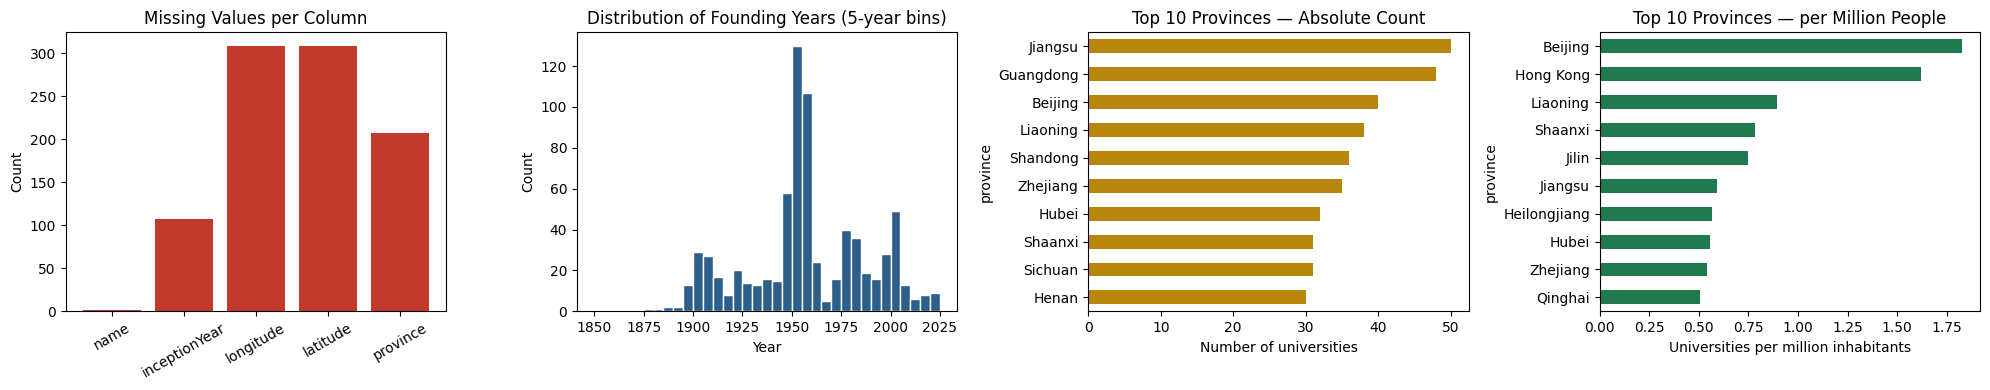

Saved to assets/eda_overview.png

Note the re-ranking from chart (3) to chart (4): the absolute-count
leader Guangdong drops out of the top 5 once population is taken
into account, while Beijing, Tianjin and Shanghai dominate.


In [14]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# ── (1) Missing-value bar ────────────────────────────────────────────────
miss = df_clean[['name','inceptionYear','longitude','latitude','province']].isnull()
axes[0].bar(miss.columns, miss.sum(), color='#c0392b')
axes[0].set_title('Missing Values per Column')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# ── (2) Founding-year histogram (5-year bins) ────────────────────────────
# 5-year bins so 1952 / 1958 / 1977 / 1999 land in distinct bins.
valid_years = df_clean['inceptionYear'].dropna()
axes[1].hist(valid_years, bins=range(1850, 2030, 5), color='#2c5f8a', edgecolor='white')
axes[1].set_title('Distribution of Founding Years (5-year bins)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')

# ── (3) Top-10 provinces by ABSOLUTE count ───────────────────────────────
top_abs = (province_summary.sort_values('count', ascending=False)
           .head(10).set_index('province')['count'].sort_values())
top_abs.plot(kind='barh', ax=axes[2], color='#b8860b')
axes[2].set_title('Top 10 Provinces — Absolute Count')
axes[2].set_xlabel('Number of universities')

# ── (4) Top-10 provinces by PER-CAPITA density ───────────────────────────
# This is the payoff of integrating the second data source: the ranking
# changes dramatically when normalised by population. Beijing/Shanghai/
# Tianjin (small populations, many universities) jump to the top, while
# Guangdong / Shandong / Henan (huge populations) drop sharply.
top_pc = (province_summary.dropna(subset=['univ_per_million'])
          .sort_values('univ_per_million', ascending=False)
          .head(10).set_index('province')['univ_per_million'].sort_values())
top_pc.plot(kind='barh', ax=axes[3], color='#1f7a4d')
axes[3].set_title('Top 10 Provinces — per Million People')
axes[3].set_xlabel('Universities per million inhabitants')

plt.tight_layout()
plt.savefig('assets/eda_overview.png', bbox_inches='tight')
plt.show()
print('Saved to assets/eda_overview.png')
print()
print('Note the re-ranking from chart (3) to chart (4): the absolute-count')
print('leader Guangdong drops out of the top 5 once population is taken')
print('into account, while Beijing, Tianjin and Shanghai dominate.')


In [15]:
# Decade × Province pivot (for RQ3 heatmap)
decade_province = df_clean.dropna(subset=['decade','province']).groupby(
    ['decade','province']
).size().reset_index(name='count')

print(f'Decade-province combinations: {len(decade_province)}')
decade_province.head(10)

Decade-province combinations: 220


,decade,province,count
0,1870,Shanghai,1
1,1880,Jiangsu,2
2,1890,Anhui,1
3,1890,Hebei,2
4,1890,Hubei,2
5,1890,Shaanxi,1
6,1890,Shandong,1
7,1890,Sichuan,1
8,1890,Zhejiang,2
9,1900,Chongqing,2


In [16]:
# Mean center per decade (for RQ4 gravity shift)
mean_center = df_clean.dropna(subset=['decade','longitude','latitude']).groupby('decade').agg(
    mean_lon = ('longitude', 'mean'),
    mean_lat = ('latitude', 'mean'),
    n_universities = ('name', 'count')
).reset_index()

# Exclude decades with too few observations — a single point cannot define
# a meaningful geographic center, and including it would mislead RQ4's
# trajectory visualization. Threshold n >= 3 chosen conservatively.
excluded = mean_center[mean_center['n_universities'] < 3]
mean_center = mean_center[mean_center['n_universities'] >= 3].reset_index(drop=True)

if len(excluded) > 0:
    print(f'Excluded {len(excluded)} decade(s) with n<3 (too few points for a center):')
    print(excluded.to_string(index=False))
    print()

print('Mean center per decade (n>=3):')
mean_center


Excluded 1 decade(s) with n<3 (too few points for a center):
 decade  mean_lon  mean_lat  n_universities
   1870 121.41315  31.22786               1

Mean center per decade (n>=3):


,decade,mean_lon,mean_lat,n_universities
0,1890,115.651181,34.360530,14
1,1900,115.531041,32.666163,45
2,1910,115.946608,33.560326,18
3,1920,114.388319,33.249044,26
4,1930,113.923187,30.985227,21
5,1940,116.456768,36.434726,52
6,1950,114.618981,33.858070,163
7,1960,114.686123,32.037164,15
8,1970,112.438305,32.175814,36
9,1980,115.521026,31.594370,39


## Step 5 – Export Clean Data

In [17]:
import os
os.makedirs('data', exist_ok=True)
os.makedirs('assets', exist_ok=True)

# Main clean dataset (with macro_region)
cols = ['univ','name','univLabel_en','univLabel_zh','inceptionYear','decade',
        'longitude','latitude','province','macro_region']
df_clean[cols].to_csv('data/universities_clean.csv', index=False)

# Aggregated datasets for visualizations
decade_province.to_csv('data/decade_province.csv', index=False)
mean_center.to_csv('data/mean_center.csv', index=False)
province_summary.to_csv('data/province_summary.csv', index=False)

# Region-level summary (for RQ2)
region_summary = df_clean.groupby('macro_region').agg(
    count=('name','count'),
    provinces=('province', lambda x: x.nunique())
).reset_index().sort_values('count', ascending=False)
region_summary.to_csv('data/region_summary.csv', index=False)

print('Exported:')
print('  data/universities_clean.csv   <- main dataset (with macro_region)')
print('  data/region_classification.csv <- secondary data source')
print('  data/decade_province.csv      <- for RQ3 heatmap')
print('  data/mean_center.csv          <- for RQ4 map trajectory')
print('  data/province_summary.csv     <- for RQ2 bar chart')
print('  data/region_summary.csv       <- for RQ2 region grouping')
print()
print(region_summary.to_string())

Exported:
  data/universities_clean.csv   <- main dataset (with macro_region)
  data/region_classification.csv <- secondary data source
  data/decade_province.csv      <- for RQ3 heatmap
  data/mean_center.csv          <- for RQ4 map trajectory
  data/province_summary.csv     <- for RQ2 bar chart
  data/region_summary.csv       <- for RQ2 region grouping

  macro_region  count  provinces
1         East    192          7
2        North     94          5
0      Central     91          3
5        South     75          4
3    Northeast     74          3
6    Southwest     59          5
4    Northwest     55          5
